# 41 · Language Model Foundations
### From characters to conditional probabilities, loss, and generation

<div style="background:#DBEAFE;border-left:6px solid #2563EB;padding:16px;border-radius:8px"><b>Learning goal.</b> Explain precisely what a language model predicts, turn a string into supervised examples, trace tensor shapes through a small network, calculate next-token loss, and distinguish training performance from useful language generalization.</div>

A language model assigns probabilities to sequences. A next-token model learns a conditional distribution: given the tokens already available, how likely is each possible next token? Repeating this prediction lets a system score text or extend a prefix. Tokens can be characters, word fragments, words, or another chosen unit. The modeling principle stays the same, but the vocabulary and meaning of a context length change.

The [code companion](41_Language_Model_Foundations.ipynb) uses the local string `deep learning ` repeated twenty times. It learns a character-level predictor with an embedding table and a linear head. This intentionally small example makes the mechanics visible; it is not a Transformer and has no downloaded training corpus.

| You should be able to explain | Evidence of understanding |
|---|---|
| What is predicted | One distribution over the next character |
| How examples are constructed | A context window and its following target |
| What training changes | Embedding and output-head parameters |
| What cross-entropy measures | Negative log probability of the observed target |
| What a low training loss establishes | Fit to the training examples |
| What needs separate evidence | Generalization, generation quality, and robust handling of new text |


<div style="background:#FEF3C7;border-left:6px solid #D97706;padding:14px;border-radius:8px"><b>Two stages in the companion.</b> The existing hand calculations and shape/parameter tables describe the opening mechanics example. The complete project at the end uses a separate model and data protocol, summarized below.</div>


## 1. The sequence probability factorization

For tokens $x_1,\ldots,x_T$, the chain rule gives

$$
p(x_1,\ldots,x_T)=\prod_{t=1}^{T}p(x_t\mid x_1,\ldots,x_{t-1}).
$$

The first factor uses an empty prefix or a start symbol, depending on the model. This factorization is a probability identity; it does not require an RNN or attention. A fixed-window model approximates each conditional using only a bounded portion of the earlier sequence.

$$
p_\theta(x_t\mid x_{<t})\approx p_\theta(x_t\mid x_{t-C},\ldots,x_{t-1}).
$$

The companion uses $C=8$. At its prediction point it sees eight characters, not eight words. It cannot use a clue that occurred earlier unless that clue is represented in those eight characters; this model has no carried recurrent state.

<div style="background:#FEF3C7;border-left:6px solid #D97706;padding:14px;border-radius:8px"><b>Conditioning is the central idea.</b> The probability of a character depends on its prefix. A frequent character can still be unlikely after a particular context. Predicting the overall frequency distribution alone ignores that relationship.</div>

| Model | Available information | Example limitation |
|---|---|---|
| Unigram | No preceding token | Same distribution after every prefix |
| Bigram | Previous token | Cannot distinguish two prefixes ending in the same token |
| Fixed-window neural model | Last $C$ tokens | No access beyond the window |
| Recurrent model | Current input and carried state | State may lose distant information |
| Causal Transformer | Earlier positions inside its context | Context still has a finite implementation limit |


## 2. Tokenization and vocabulary IDs

Tokenization chooses the units; numericalization maps those units to integer IDs. An ID is an index, not a semantic magnitude. Character ID 9 is not intrinsically more meaningful than ID 2. The embedding table supplies learned vector representations.

The companion builds `alphabet = sorted(set(text))`. Its ten characters and IDs are:

| Character | ID | Character | ID |
|---|---|---|---|
| Space | 0 | `i` | 5 |
| `a` | 1 | `l` | 6 |
| `d` | 2 | `n` | 7 |
| `e` | 3 | `p` | 8 |
| `g` | 4 | `r` | 9 |

`deep learning ` has fourteen characters including both spaces. Twenty repetitions contain 280 characters. The alphabet includes no padding, unknown-token, or start/end IDs. A new character such as `!` has no entry in this mapping. Handling it requires an explicit design change; it will not acquire a valid ID automatically.

| Token unit | Advantage | Tradeoff |
|---|---|---|
| Character | Small vocabulary, visible spelling | Many positions needed for long text |
| Word | Units correspond to whole words | Unseen words require a policy |
| Subword | Reuses frequent word fragments | Boundaries and token lengths vary |
| Byte | Fixed byte inventory can encode text | A visible character may use several bytes |

A hypothetical split such as `learn` + `ing` illustrates subwords; it is not the result of a specific tokenizer here. When preparing a held-out experiment, define the vocabulary using the training data or a fixed external tokenizer, and decide how unseen units are represented.


## 3. Build a context and shifted targets by hand

The first eight input characters are `deep lea`. The shifted target row is `eep lear`: each target is one position later than the corresponding input character.

| Position in row | Input | Input ID | Shifted target | Target ID |
|---|---|---|---|---|
| 0 | `d` | 2 | `e` | 3 |
| 1 | `e` | 3 | `e` | 3 |
| 2 | `e` | 3 | `p` | 8 |
| 3 | `p` | 8 | Space | 0 |
| 4 | Space | 0 | `l` | 6 |
| 5 | `l` | 6 | `e` | 3 |
| 6 | `e` | 3 | `a` | 1 |
| 7 | `a` | 1 | **`r`** | **9** |

There are $280-8=272$ windows. The last starts at index 271 and uses characters 271 through 278 to predict character 279. Neighboring windows overlap heavily, so these are not 272 independent pieces of language knowledge.

<div style="background:#FCE7F3;border-left:6px solid #DB2777;padding:14px;border-radius:8px"><b>Read the target selection carefully.</b> Training uses <code>targets[selection, -1]</code>. Only the last target in each row contributes to loss. The model does not produce eight separate next-character distributions.</div>

The full input window is allowed for predicting its following character. No causal attention mask is needed in this architecture because there is no prediction at an earlier position that could accidentally read a later input position. If the architecture were changed to predict all eight shifted targets, visibility would need to be reconsidered.


## 4. Trace the network and every tensor shape

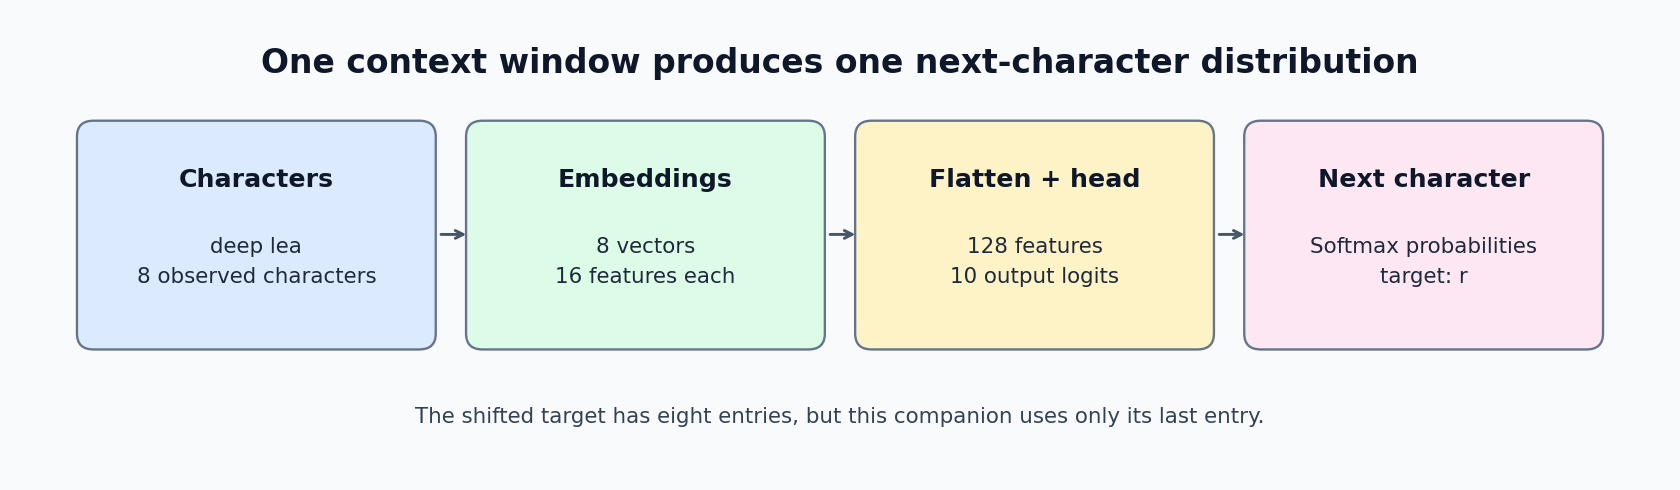

| Stage | Full data or minibatch shape | Meaning |
|---|---|---|
| All input windows | `[272, 8]` | Eight character IDs per example |
| All shifted targets | `[272, 8]` | Constructed target rows |
| Sampled inputs | `[32, 8]` | Windows chosen for one update |
| Embedding output | `[32, 8, 16]` | Sixteen learned features per character |
| Flattened output | `[32, 128]` | Eight ordered vector slots |
| Linear head logits | `[32, 10]` | One score for each character |
| Selected targets | `[32]` | Last target ID per window |
| Cross-entropy | Scalar | Mean loss across the batch |

The embedding has $10\times16=160$ parameters. The linear head has $128\times10+10=1290$, including biases. Total: **1,450 trainable parameters**.

Flattening preserves the order of the slots. The head has separate coefficients for each position, so swapping two characters generally changes the output. The embedding table is shared across positions, but the head's position-specific weights make the complete model order-sensitive. There is no explicit positional-encoding layer, recurrence, or attention.


## 5. Logits become probabilities

For logits $z_1,\ldots,z_V$, softmax defines

$$
p_j=\frac{e^{z_j}}{\sum_{k=1}^{V}e^{z_k}}.
$$

A numerically stable implementation subtracts the largest logit before exponentiation. Adding the same constant to every logit leaves the probabilities unchanged. Raw logits need not be positive or sum to one.

Consider a teaching vocabulary of three tokens with logits $[\ln2,0,0]$. Exponentials are $[2,1,1]$, so probabilities are $[0.5,0.25,0.25]$.

| Quantity | Token A | Token B | Token C |
|---|---|---|---|
| Logit | $\ln2$ | 0 | 0 |
| Exponential | 2 | 1 | 1 |
| Probability | 0.50 | 0.25 | 0.25 |
| Target indicator if B is correct | 0 | 1 | 0 |

These three tokens are an arithmetic example, separate from the companion's ten-character vocabulary. A classification decision selects one token, but training uses the whole score vector to raise the target's relative probability.

PyTorch cross-entropy expects logits and integer target IDs in this companion. Applying softmax first changes the input expected by that loss; compute probabilities separately when inspecting or sampling.


## 6. Calculate next-token loss and a gradient

For observed target $y$, negative log likelihood is

$$
L=-\log p_y,\qquad \frac{\partial L}{\partial z_j}=p_j-\mathbf{1}[j=y].
$$

For target B above, $L=-\ln0.25=1.386294$ nats. The logit gradient is $[0.5,-0.75,0.25]$. A small gradient-descent update to these logits would lower A and C and raise B. This arithmetic illustrates the output derivative; the actual optimizer updates shared network parameters rather than storing independently adjustable logits for each window.

| Target probability | Loss in nats | Interpretation |
|---|---|---|
| 0.90 | 0.105361 | Target is strongly favored |
| 0.50 | 0.693147 | Moderate uncertainty |
| 0.25 | 1.386294 | Target receives one quarter of the mass |
| 0.10 | 2.302585 | Same loss as a uniform ten-way prediction |

The gradient continues through the linear head into embeddings used in the selected contexts. Repeated uses of an embedding row accumulate contributions. The discrete token IDs themselves are not learned by gradient descent.

For a mean minibatch loss, each example's contribution is scaled by the batch size. Forgetting this distinction can make a hand-computed gradient appear 32 times larger than the companion's mean-loss gradient.


## 7. Sequence scores and perplexity

Suppose the probabilities assigned to three observed target tokens are $0.5$, $0.25$, and $0.125$. Their joint conditional probability is $1/64$. Their summed negative log probability is $\ln64=4.158883$; the mean is $\ln4=1.386294$.

$$
\mathrm{PPL}=\exp\left(-\frac{1}{N}\sum_{t=1}^{N}\log p_\theta(x_t\mid\text{context}_t)\right).
$$

Perplexity is therefore 4 for these three targets. It describes predictive uncertainty through the geometric mean of target probabilities. It is not the percentage of correct predictions. A uniform ten-token predictor has loss $\ln10$ and perplexity 10.

<div style="background:#DCFCE7;border-left:6px solid #16A34A;padding:14px;border-radius:8px"><b>Compare like with like.</b> Perplexity depends on tokenization, vocabulary, evaluation text, and which positions contribute to the loss. Character-level and subword-level perplexities are not directly interchangeable.</div>

For unequal-length batches, aggregate the total negative log likelihood and total number of evaluated targets before dividing. Averaging batch means equally would overweight shorter batches. The opening fixed-window example reports training loss only. The second sentence-level GRU project computes token-weighted held-out loss and character perplexity.


## 8. What the companion's training loop actually does

The random seed is 41. On each of 100 updates, the code samples 32 window indices using `torch.randint`, computes logits, compares them with final target IDs, clears gradients, backpropagates, and takes an Adam step with learning rate 0.02. Sampling is with replacement; an example can appear twice in one batch.

| Operation | Purpose | Evidence limit |
|---|---|---|
| Seed the random generator | Make the run reproducible in a fixed environment | Does not establish robustness across seeds |
| Draw random windows | Supply examples for an update | No explicit shuffled epoch pass |
| Compute cross-entropy | Train the next-character distribution | Only selected final targets count |
| Check finite loss | Catch NaN or infinite loss | Does not require good predictions |
| Predict from `inputs[:1]` | Inspect one next-character choice | This input was part of the training data |

Because every update samples new indices, 100 updates do not mean exactly 100 epochs. The printed `loss` is the final sampled minibatch's training loss, not an average over the entire corpus and not a validation score.

The repeated phrase has very little variety. Learning its cycle can drive training loss down without learning grammar, meaning, or useful behavior on unfamiliar sentences. An expected target for the first window is `r`; the notes identify the ground truth without claiming an executed training result.


## 9. Generation: use predictions to create new inputs

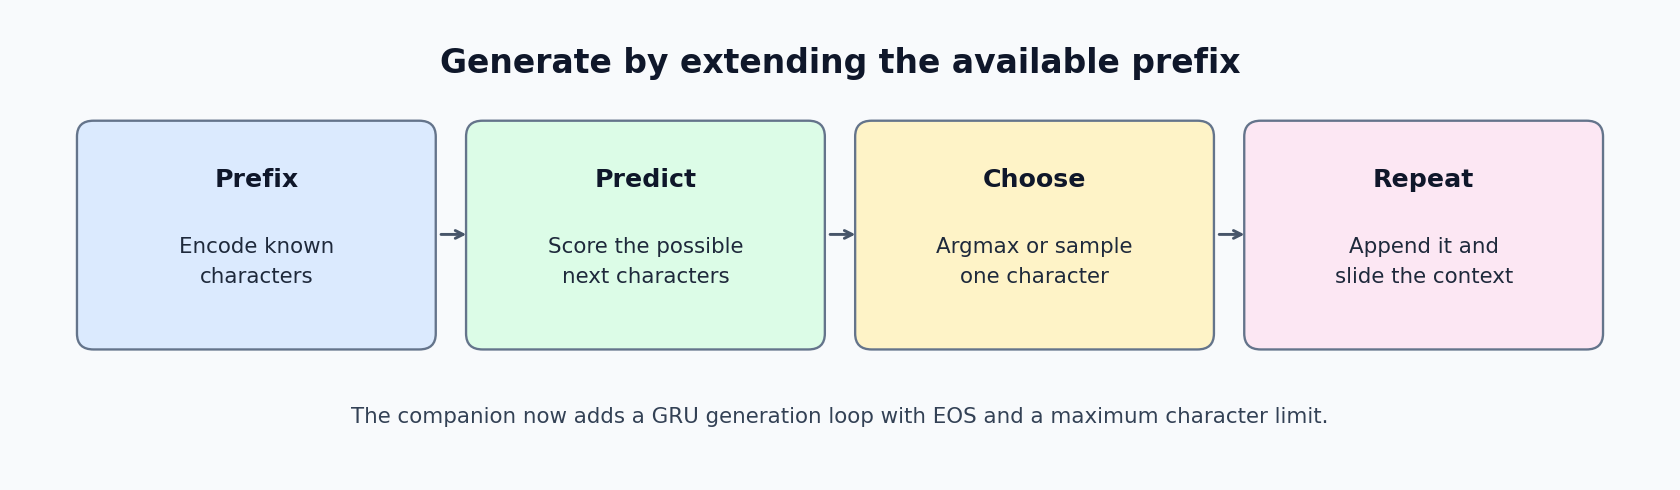

A generation extension would encode a prefix of at least eight known characters, retain its last eight IDs, run the model, choose one next ID, append its decoded character, and repeat. The newly generated token becomes part of the next context. Errors can therefore influence later predictions.

| Choice rule | What it does | Consequence |
|---|---|---|
| Greedy argmax | Always take the highest-scoring token | Deterministic for fixed logits |
| Categorical sampling | Draw according to probabilities | More variation, including unlikely tokens |
| Temperature | Use softmax of logits divided by positive $T$ | Lower $T$ concentrates; higher $T$ flattens |
| Top-k sampling | Retain k highest-scoring candidates, renormalize | Removes candidates outside that set |
| Stopping policy | Stop at a limit or designated token | Must be defined explicitly |

The opening fixed-window example has no end-of-sequence token or generation loop. The second project introduces EOS and bounded recurrent generation. A maximum character count is a suitable stopping policy for an extension. A prefix shorter than eight characters needs a separately designed padding or initialization policy because the linear head expects 128 flattened features.

For greedy decoding, a positive temperature preserves logit order, so it does not change the argmax. Temperature affects sampling probabilities; it does not give the trained model access to new knowledge.


## 10. Teacher forcing and prediction-time feedback

Training contexts contain observed text. This is a form of teacher-forced conditioning: the model learns from true earlier tokens rather than from its own earlier mistakes. During free generation, earlier sampled tokens may differ from the observed training pattern.

| Situation | Prefix source | What is measured |
|---|---|---|
| Training | Observed training text | Loss used to update parameters |
| Held-out likelihood | Observed held-out text | Probability assigned to actual continuations |
| Free generation | User prefix and model-generated tokens | Behavior over a growing generated sequence |

Good held-out next-token loss and pleasing samples answer related but different questions. A single generated phrase can look correct by luck, while an aggregate likelihood calculation evaluates many observed targets. Conversely, lower likelihood loss does not guarantee that every generated sample will meet a user's task.

Connect this lesson to [sequence modeling](25_Sequence_Modeling_Notes.ipynb), [BERT](31_BERT_and_Encoder_Models_Notes.ipynb), and [GPT](32_GPT_and_Autoregressive_Models_Notes.ipynb). A masked-token objective may use both sides of a hidden token; this next-token objective uses its available earlier context. The objective and visibility rule matter independently of the architecture name.


## 11. Design a trustworthy evaluation

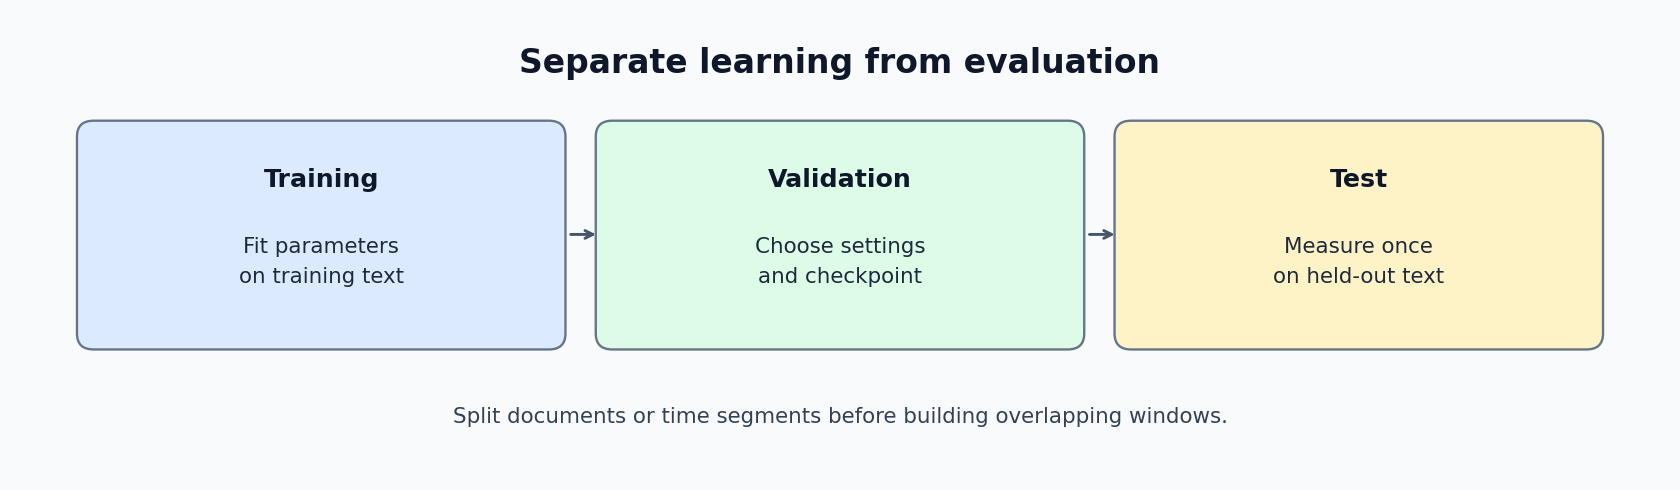

Split original documents or chronological text segments before constructing windows. Randomly splitting heavily overlapping windows can place nearly identical contexts in training and test sets. With the repeated phrase here, even nonoverlapping segments contain the same cycle, so a holdout still would not measure broad language generalization.

| Baseline or check | Why include it |
|---|---|
| Uniform vocabulary probabilities | Establish the ten-way uncertainty reference |
| Training-character frequencies | Check whether context improves on unigram prediction |
| Bigram counts with an explicit unseen-context policy | Test improvement beyond very short dependencies |
| Held-out negative log likelihood | Measure prediction on excluded examples |
| Several prefixes and seeds | Inspect variation and failure cases |
| Unseen-character test | Confirm vocabulary handling is deliberate |

In the repeated phrase, `e` occurs 3 times per 14 characters, `n` and space each occur twice, and every other alphabet character occurs once. These frequencies describe the full teaching string; a real baseline should estimate its frequencies from training data. A simple bigram already predicts `r` after `a` in this phrase, so one correct example does not establish the value of the neural architecture.


## 12. Troubleshooting checklist

| Symptom | Likely cause | Concrete inspection |
|---|---|---|
| Head input-size error | Context or embedding width changed | Check flattened width equals $C\times d$ |
| Cross-entropy shape error | Full target matrix passed to a single-output head | Verify logits `[B,V]`, targets `[B]` |
| Token lookup error | Character outside vocabulary | Inspect mapping and unknown-token policy |
| Low training loss, poor new text | Memorization or distribution mismatch | Evaluate excluded text with meaningful variety |
| Apparent test success on repeats | Overlap or repeated-pattern leakage | Inspect raw split boundaries and duplicates |
| Repeated generations | Narrow training distribution or decoding policy | Compare probabilities and multiple sampled runs |
| NaN loss | Unstable arithmetic or optimization | Inspect logits, loss, and gradients for finiteness |

Before changing model size, print one decoded input window and its selected target. This often reveals an off-by-one error more directly than a long training run. Then verify the shape chain, loss input, optimizer step, and evaluation split.

<div style="background:#EDE9FE;border-left:6px solid #7C3AED;padding:14px;border-radius:8px"><b>Keep three claims separate.</b> Correct tensor shapes show that operations are compatible. A decreasing training loss shows that optimization fits the supplied examples. Held-out results are needed to support a generalization claim.</div>


## 13. Practice with worked answers

1. **How many examples come from 50 characters with context length 8 using this construction?** $50-8=42$. Each example needs eight inputs and one following target.
2. **What are the final target and its ID for `deep lea`?** Character `r`, ID 9. The other shifted targets are constructed but unused by this head.
3. **A batch has 12 examples, context 8, embedding width 16, vocabulary 10. What are logits and target shapes?** `[12,10]` and `[12]`; flattening gives `[12,128]`.
4. **A target receives probability 0.2. What is its loss?** $-\ln0.2=1.609438$ nats. If every evaluated target receives 0.2, perplexity is 5.
5. **Does the model ignore order because it uses no positional encoding?** No. Flattening assigns each embedding to a distinct input slot of the linear head.
6. **Why is a random window split weak here?** Windows overlap, and the same fourteen-character phrase repeats throughout the text.
7. **Does lowering temperature improve greedy decoding?** It preserves the argmax for positive temperature; sampling behavior changes instead.
8. **What generation does the companion implement?** The opening fixed-window example prints one prediction. The complete GRU project generates bounded continuations until EOS or a character limit; its controlled sentence corpus does not demonstrate paragraph-level competence.

### A practical extension sequence

First verify several decoded context/target pairs. Next calculate full-corpus training loss without updating parameters. Then prepare genuinely distinct text segments and a vocabulary policy, compare unigram and bigram baselines, and add a bounded generation loop. Only after these checks should a larger recurrent or causal attention model be used to study longer context.

Continue to [the full course review](42_Deep_Learning_Foundations_Review_Notes.ipynb) to connect language modeling with the same prediction, loss, gradient, and evaluation principles used across the course.


## Complete project walkthrough: held-out character likelihood and generation

<div style="background:#DBEAFE;border-left:6px solid #2563EB;padding:16px;border-radius:8px"><b>From repeated-string mechanics to a complete learning protocol.</b> The second project uses distinct documents, validation-selected weights, held-out likelihood, unigram/bigram baselines, and a bounded generation loop. A GRU makes recurrent context and incremental decoding explicit.</div>

The local corpus contains 256 unique sentences combining colors, animals, actions, and places. A seeded document-level split assigns 192/32/32 to training/validation/test before numerical encoding. Exact sentences never cross partitions. Training characters determine the vocabulary, with four explicit special IDs; unfamiliar characters map to UNK during encoding and unknown user-prefix characters are rejected by generation.

| Component | Second-project configuration |
|---|---|
| Vocabulary | 27 entries, including PAD/BOS/EOS/UNK |
| Character embedding | 24 features |
| Recurrent layer | Unidirectional GRU, hidden width 64 |
| Output head | 64 features to 27 logits per position |
| Parameters | 19,683 |
| Train input/target shift | Remove final column / remove first column |
| Loss | Mean over actual non-PAD targets, including EOS |
| Training budget | 60 epochs, six batches per epoch: 360 updates |

Unlike the first flattened fixed-window model, the GRU predicts every shifted target. Rows are padded on the right after EOS. Every document starts with a new hidden state. Future right padding cannot affect earlier valid states in a unidirectional recurrence, and PAD labels are excluded from the loss.


### Fit, preserve, and compare

Adam uses learning rate 0.005 with gradient clipping at norm 1.0. At every epoch, token-weighted training and validation NLL are recomputed without updates. The lowest-validation-NLL state is deep-copied and restored. Test evaluation sums negative log likelihood over valid targets before dividing by their count, so different sentence lengths do not change the intended weighting.

The unigram baseline estimates a distribution independent of the prefix. The bigram baseline uses the preceding character, including BOS. Both use training counts with additive smoothing and exclude PAD/BOS as output candidates. They expose whether the learned context improves beyond simple character statistics. Report character perplexity as $\exp(\text{mean NLL})$; it is not numerically interchangeable with word-token perplexity.


### Generate while carrying the right state

Encode BOS and the prefix, run that prefix once, then repeatedly select the final distribution's next character. After selection, feed only that new character and carry the prior hidden state. Reprocessing the entire prefix while retaining its already-used hidden state would count the prefix twice. An independent assertion checks that incremental decoding agrees with a fresh full-prefix pass.

| Generation rule | Complete-project behavior |
|---|---|
| Greedy | Choose highest allowed score |
| Sampling | Draw from temperature-scaled probabilities |
| Special outputs | PAD, BOS, and UNK excluded |
| Stopping | EOS or a maximum number of new characters |
| Unknown prefix character | Explicit error rather than silent replacement |
| Reproducibility | A local seeded sampling generator |

Padding assertions verify both valid-logit invariance and unchanged summed loss after appending ignored positions. Generation checks include identical samples for identical seeds, a character limit, a zero-new-character request, and unknown-character rejection.

The held-out sentences recombine familiar grammar pieces. They do not establish competence on arbitrary text, longer discourse, or new vocabulary. Generated sentences may repeat known combinations, and a few readable samples cannot replace the aggregate held-out measurements. Compare this character model with the [word-token Transformer project](32_GPT_and_Autoregressive_Models.ipynb) by protocol and behavior, rather than directly comparing their perplexity numbers.


## Executed reference run: Character GRU

<div style="background:#DCFCE7;border-left:6px solid #16A34A;padding:14px;border-radius:8px"><b>Measured results.</b> Selected epoch: 39. Test NLL: **0.1676**, character perplexity: **1.183**, character accuracy: **0.9047**. Unigram perplexity: 15.759; bigram perplexity: 3.882. Sample: `the green bird sits near the garden`.</div>

These outputs were obtained by running every code cell in a fresh CPU kernel with the repository’s virtual environment. They describe this fixed synthetic experiment, not performance on arbitrary real-world data.

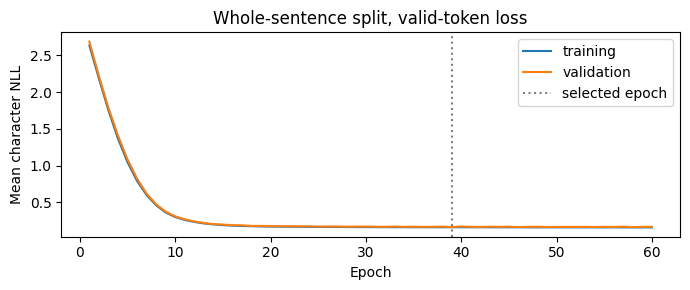
